In [21]:
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv(find_dotenv())

path = os.getenv('DATA_SOURCE')
path1 = 'churndata.csv'

In [22]:
# Read data from csv file and create DataFrame:
csv_data = pd.read_csv(path1,sep=';')
df = pd.DataFrame(csv_data)

/tmp/ipykernel_7828/3832040353.py:2: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_data = pd.read_csv(path1,sep=';')


In [23]:
# Dataset size:
shape = df.shape
print(f"Row count: {shape[0]}")
print(f"Column count: {shape[1]}")

Row count: 100076
Column count: 32


In [24]:
# Data type of each column:
data_type = df.info()
print(data_type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100076 entries, 0 to 100075
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  100076 non-null  object 
 1   signup_date                  100076 non-null  object 
 2   age                          100076 non-null  int64  
 3   gender                       100076 non-null  object 
 4   annual_income                97109 non-null   float64
 5   education                    100076 non-null  object 
 6   marital_status               100076 non-null  object 
 7   dependents                   100076 non-null  int64  
 8   tenure                       100076 non-null  int64  
 9   contract                     100076 non-null  object 
 10  payment_method               100076 non-null  object 
 11  paperless_billing            100076 non-null  object 
 12  senior_citizen               100076 non-null  int64  
 13 

## Data Issues:

- Column **MonthlyCharges & TotalCharges**: Đang là `string` → cần kiểm tra dữ liệu và convert sang numeric  
- Column **avg_monthly_gb**: Kiểu `object` → cần inspect và chuẩn hóa (có thể chứa dữ liệu không nhất quán)

In [25]:
# Quick view first and last 5 data rows:
head = df.head()
tail = df.tail()
print(f"First 5 rows: \n", head)
print(f"Last 5 rows: \n", tail)

First 5 rows: 
       customer_id                 signup_date  age  gender  annual_income  \
0  CUST0000000001  2022-12-12 12:53:58.199463   43  Female       55085.25   
1  CUST0000000002  2022-01-13 12:53:58.199973   18    Male       60786.11   
2  CUST0000000003  2023-09-04 12:53:58.199985   38  Female       73184.32   
3  CUST0000000004  2022-06-27 12:53:58.199992   44    Male       40923.78   
4  CUST0000000005  2022-12-08 12:53:58.199999   45  Female       36400.94   

     education marital_status  dependents  tenure  contract  ...  \
0      college        married           1       2  two_year  ...   
1       master        married           1      22  one_year  ...   
2  high_school        widowed           0       3  two_year  ...   
3  high_school        married           1       6  two_year  ...   
4     bachelor         single           0       9  two_year  ...   

  has_streaming_tv has_streaming_movies  customer_satisfaction num_complaints  \
0                1             

In [26]:
# Data distribution:

# For numerical columns:
desc_num = df.describe()
print("Describing numerical columns:")
print(desc_num)

Describing numerical columns:
                 age  annual_income     dependents         tenure  \
count  100076.000000   97109.000000  100076.000000  100076.000000   
mean       44.755426   58737.060994       0.802270      22.465726   
std        14.487604   37119.230979       0.893909      20.045964   
min        18.000000   20000.000000       0.000000       1.000000   
25%        34.000000   32645.730000       0.000000       7.000000   
50%        45.000000   48790.090000       1.000000      16.000000   
75%        55.000000   73265.340000       1.000000      33.000000   
max        90.000000  250000.000000       5.000000      72.000000   

       senior_citizen   num_services  has_phone_service  has_internet_service  \
count   100076.000000  100076.000000      100076.000000         100076.000000   
mean         0.199358       2.563642           0.769885              0.850514   
std          0.399520       1.411497           0.420908              0.356569   
min          0.000000   

In [27]:
# For categorical columns:
desc_cate = df.select_dtypes(include="object")
print("Describing categorical columns:")

for col_name, col_data in desc_cate.items():
    print(col_name)
    print(f"Value distribution: {col_data.value_counts()}") # Count records of each type
    print(f"Count of unique value: {col_data.nunique()}") # Count unique values
    print(f"Most frequent data: {col_data.mode()[0]}") # Define most frequent data
    print("\n\n")

Describing categorical columns:
customer_id
Value distribution: customer_id
CUST0000100076    1
CUST0000000001    1
CUST0000000002    1
CUST0000000003    1
CUST0000000004    1
                 ..
CUST0000000017    1
CUST0000000016    1
CUST0000000015    1
CUST0000000014    1
CUST0000000013    1
Name: count, Length: 100076, dtype: int64
Count of unique value: 100076
Most frequent data: CUST0000000001



signup_date
Value distribution: signup_date
2023-11-11 12:53:59.335264    1
2022-12-12 12:53:58.199463    1
2022-01-13 12:53:58.199973    1
2023-09-04 12:53:58.199985    1
2022-06-27 12:53:58.199992    1
                             ..
2022-12-15 12:53:58.200070    1
2022-03-17 12:53:58.200064    1
2025-10-16 12:53:58.200058    1
2021-12-21 12:53:58.200053    1
2025-02-15 12:53:58.200047    1
Name: count, Length: 100076, dtype: int64
Count of unique value: 100076
Most frequent data: 2021-01-13 12:53:58.205311



gender
Value distribution: gender
Female    49171
Male      48848
Other     

In [28]:
# Detect rows that are fully duplicated:
duplicate = df.duplicated().sum()
print(duplicate)

0


In [29]:
##II. Process missing value data
#II.1. Kiểm tra các cột có giá trị Na -- Detect column with Na value
na_columns = df.columns[df.isna().any()]
na_info = pd.DataFrame({
    'No of Na': df[na_columns].isna().sum(),
    'Type of data': df[na_columns].dtypes})
print("The columns with Na value are:")
print(na_info)


The columns with Na values are:
                       No of Na Type of data
annual_income              2967      float64
customer_satisfaction      2012      float64
num_complaints             2993      float64
avg_monthly_gb             5124       object
credit_score               4161      float64


In [30]:
# II.2. Xử lý cột có Na cần chuẩn hóa cột avg_monthly_gb (thay thế các case dữ liệu sai ký tự ngăn cách từ , thành . và biến thành float)
# Standardize the column avg_monthly_gb to replace Na value
df['avg_monthly_gb'] = df['avg_monthly_gb'].astype(str).str.replace(r'\.(?=\d{3})', ',', regex=True)
df['avg_monthly_gb'] = pd.to_numeric(df['avg_monthly_gb'], errors='coerce')
print(df['avg_monthly_gb'])


0         109.63
1          63.25
2          47.77
3          50.82
4          16.74
           ...  
100071      0.00
100072      0.00
100073      9.82
100074     33.72
100075     63.07
Name: avg_monthly_gb, Length: 100076, dtype: float64


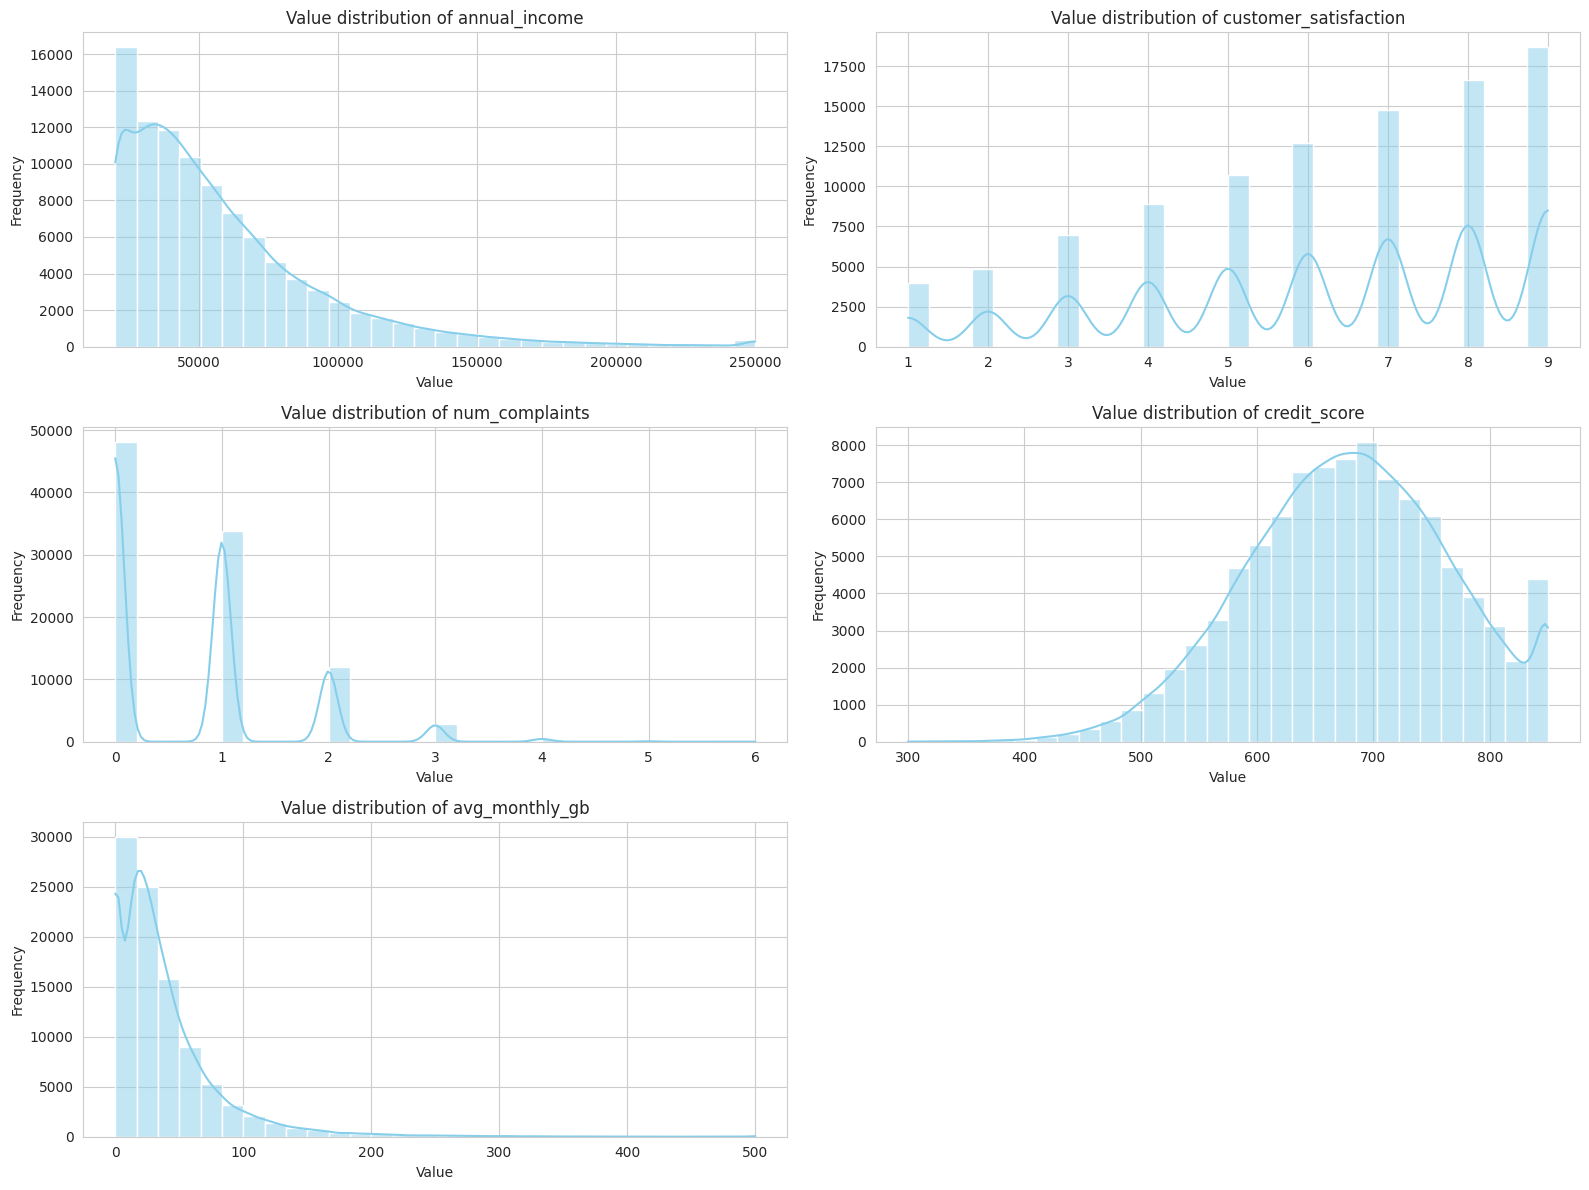

In [31]:
# II.3. Nhận diện các cột phân bố giá trị không đồng đều để lựa chọn sử dụng thay giá trị Na của cột thành mean hay median
# Visualize to identify the distribution of data column & replace Na with mean/ median
cols_to_plot = ['annual_income', 'customer_satisfaction', 'num_complaints', 'credit_score', 'avg_monthly_gb']
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=30)
    plt.title(f'Value distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Các cột sử dụng mean: 'customer_satisfaction'
## Các cột sử dụng median: 'annual_income', 'credit_score', 'avg_monthly_gb',  'num_complaints'

median_val = df['customer_satisfaction'].median()
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(median_val)

cols_median = ['annual_income', 'credit_score', 'avg_monthly_gb', 'num_complaints']
for col in cols_median:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)


In [32]:

# II.4. Kiểm tra lại sau khi xử lý còn cột nào chứa giá trị Na không -- Recheck whether any Na value in the data
print(df.isna().sum())

customer_id                    0
signup_date                    0
age                            0
gender                         0
annual_income                  0
education                      0
marital_status                 0
dependents                     0
tenure                         0
contract                       0
payment_method                 0
paperless_billing              0
senior_citizen                 0
monthlycharges                 0
totalcharges                   0
num_services                   0
has_phone_service              0
has_internet_service           0
has_online_security            0
has_online_backup              0
has_device_protection          0
has_tech_support               0
has_streaming_tv               0
has_streaming_movies           0
customer_satisfaction          0
num_complaints                 0
num_service_calls              0
late_payments                  0
avg_monthly_gb                 0
days_since_last_interaction    0
credit_sco